In [1]:
import numpy as np
from bigfile import BigFile
import matplotlib.pyplot as plt
from profile_funcs import *

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-0fci61ic because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# indices for z = 0, 0.2, 0.5, 1.0 
z_list = [0.0, 0.2, 0.5, 1.0]
idx_kn1DF = [21, 18, 15, 13]
idx_kn1R1 = [21, 17, 15, 13]
idx_kn0R1 = [21, 18, 15, 13]
idx_dmo = [19, 16, 14, 12]

In [3]:
# load pigs
dir_parent = '/scratch3/01317/yyang440/small_subfind'
pigs_kn1DF = [BigFile(f'{dir_parent}/kn1-DF/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1DF]
pigs_kn1R1 = [BigFile(f'{dir_parent}/kn1-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1R1]
pigs_kn0R1 = [BigFile(f'{dir_parent}/kn0-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn0R1]
pigs_dmo    = [BigFile(f'{dir_parent}/dmo/{i:03d}/PIG_{i:03d}_subfind') for i in idx_dmo]

labels_sim = ['Kn1-DF', 'Kn1-Repos1', 'Kn0-Repos1', 'DMO']


In [4]:
# only consider z = 0 for now
idx_z = 0

r_kn1DF, rho_kn1DF = get_rho_profile(pigs_kn1DF[idx_z])
r_kn1R1, rho_kn1R1 = get_rho_profile(pigs_kn1R1[idx_z])
r_kn0R1, rho_kn0R1 = get_rho_profile(pigs_kn0R1[idx_z])
r_dmo,    rho_dmo    = get_rho_profile(pigs_dmo[idx_z])

/scratch3/01317/yyang440/tapis/dcaaf8a9-e4dc-4856-a8ed-137a838b39d0-007/Work/frontera/Astrid_analyses/mass_profile/profile_funcs.py:41: RuntimeWarning: invalid value encountered in divide
  density_prof = mass_shell / vol_shell


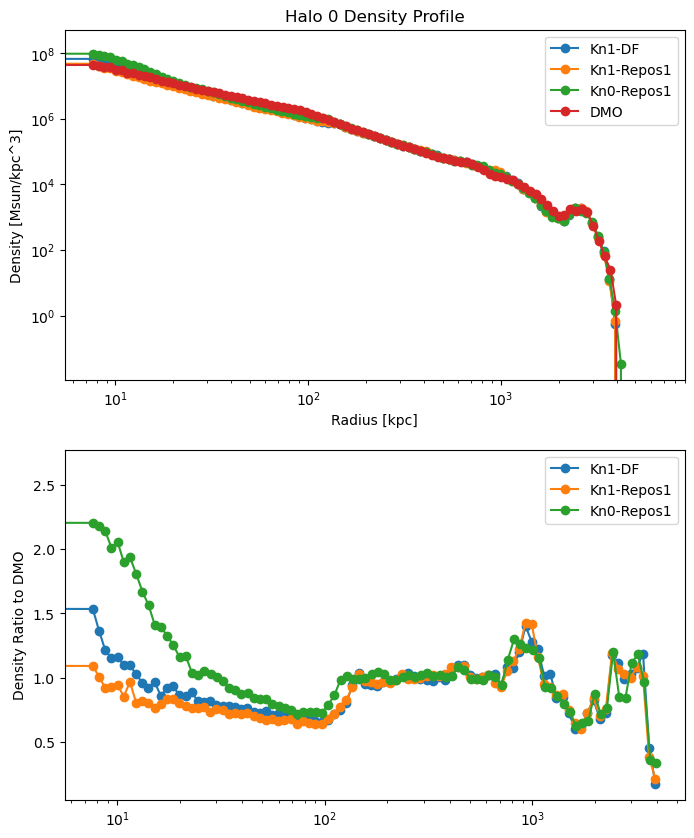

In [5]:
# make a plot of density profile

# only plot halo 0 in each simulation
idx_halo = 0

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].plot(r_kn1DF[idx_halo], rho_kn1DF[idx_halo], marker='o', label='Kn1-DF')
axes[0].plot(r_kn1R1[idx_halo], rho_kn1R1[idx_halo], marker='o', label='Kn1-Repos1')
axes[0].plot(r_kn0R1[idx_halo], rho_kn0R1[idx_halo], marker='o', label='Kn0-Repos1')
axes[0].plot(r_dmo[idx_halo],    rho_dmo[idx_halo],    marker='o', label='DMO')

# ratio of hydro to DMO
r_common, ratio_kn1DF = get_profile_ratio(r_dmo[idx_halo], rho_dmo[idx_halo], r_kn1DF[idx_halo], rho_kn1DF[idx_halo])
axes[1].plot(r_common, ratio_kn1DF, marker='o', label='Kn1-DF')
r_common, ratio_kn1R1 = get_profile_ratio(r_dmo[idx_halo], rho_dmo[idx_halo], r_kn1R1[idx_halo], rho_kn1R1[idx_halo])
axes[1].plot(r_common, ratio_kn1R1, marker='o', label='Kn1-Repos1')
r_common, ratio_kn0R1 = get_profile_ratio(r_dmo[idx_halo], rho_dmo[idx_halo], r_kn0R1[idx_halo], rho_kn0R1[idx_halo])
axes[1].plot(r_common, ratio_kn0R1, marker='o', label='Kn0-Repos1')

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Radius [kpc]')
axes[0].set_ylabel('Density [Msun/kpc^3]')
axes[0].set_title(f'Halo {idx_halo} Density Profile')

# legend
axes[0].legend()
axes[1].set_xscale('log')
axes[1].set_ylabel('Density Ratio to DMO')
axes[1].legend()
plt.show()

In [6]:
# plot stacked density profile
def plot_stacked(ax, r, rho_median, rho_p16, rho_p84, label_sim, color):
    ax.fill_between(r, rho_p16, rho_p84, alpha=0.3, color=color)
    ax.plot(r, rho_median, label=label_sim, color=color)
    

/scratch3/01317/yyang440/tapis/dcaaf8a9-e4dc-4856-a8ed-137a838b39d0-007/Work/frontera/Astrid_analyses/mass_profile/profile_funcs.py:16: RuntimeWarning: divide by zero encountered in log
  f = interp1d(np.log(r_src_nonzero), np.log(y_src_nonzero), kind='linear', fill_value='extrapolate')
/work2/01317/yyang440/frontera/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in subtract
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/scratch3/01317/yyang440/tapis/dcaaf8a9-e4dc-4856-a8ed-137a838b39d0-007/Work/frontera/Astrid_analyses/mass_profile/profile_funcs.py:165: RuntimeWarning: divide by zero encountered in log10
  log_rho = np.log10(density_prof_interp)


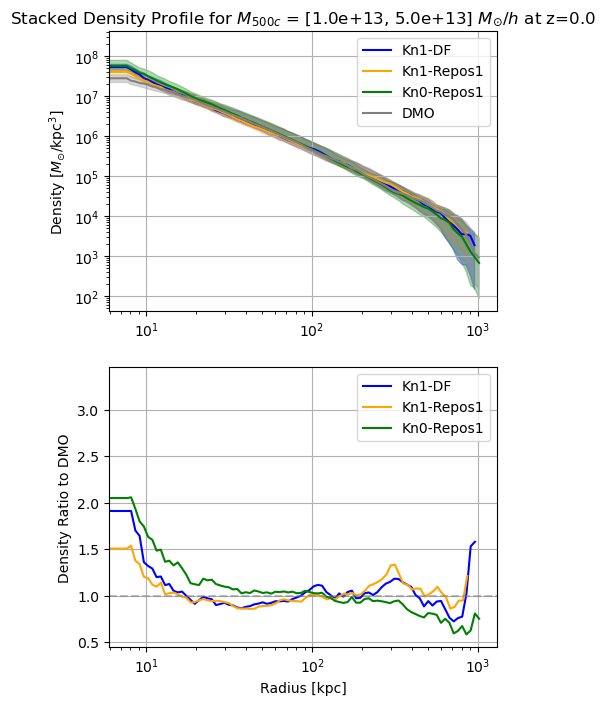

In [7]:
# stacked density profile, 1e13 to 5e13 Msun/h

colors = ['blue', 'orange', 'green']

m_lower, m_upper = 1e13, 5e13

fig, axes = plt.subplots(2, 1, figsize=(5, 8))

r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF = get_stacked_rho_profile(pigs_kn1DF[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF, 'Kn1-DF', colors[0])
r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1 = get_stacked_rho_profile(pigs_kn1R1[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1, 'Kn1-Repos1', colors[1])
r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1 = get_stacked_rho_profile(pigs_kn0R1[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1, 'Kn0-Repos1', colors[2])
r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo = get_stacked_rho_profile(pigs_dmo[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo, 'DMO', 'gray')

# ratio of hydro to DMO
r_common, ratio_kn1DF = get_profile_ratio(r_dmo, rho_dmo, r_kn1DF, rho_kn1DF)
axes[1].plot(r_common, ratio_kn1DF, label='Kn1-DF', color=colors[0])
r_common, ratio_kn1R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1R1, rho_kn1R1)
axes[1].plot(r_common, ratio_kn1R1, label='Kn1-Repos1', color=colors[1])
r_common, ratio_kn0R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn0R1, rho_kn0R1)
axes[1].plot(r_common, ratio_kn0R1, label='Kn0-Repos1', color=colors[2])

# horizontal line at y=1
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)


# grid true
for ax in axes:
    ax.grid(True)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_xlabel('Radius [kpc]')
axes[0].set_ylabel(r'Density [$M_{\odot}/\mathrm{kpc}^3$]')
axes[0].set_title(f'Stacked Density Profile for $M_{{500c}}$ = [{m_lower:.1e}, {m_upper:.1e}] $M_{{\odot}}/h$ at z={z_list[idx_z]}')

# legend
axes[0].legend()
axes[1].set_xscale('log')
axes[1].set_ylabel('Density Ratio to DMO')
axes[1].legend()
plt.show()

/work2/01317/yyang440/frontera/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:4527: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/work2/01317/yyang440/frontera/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:4529: RuntimeWarning: invalid value encountered in add
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))


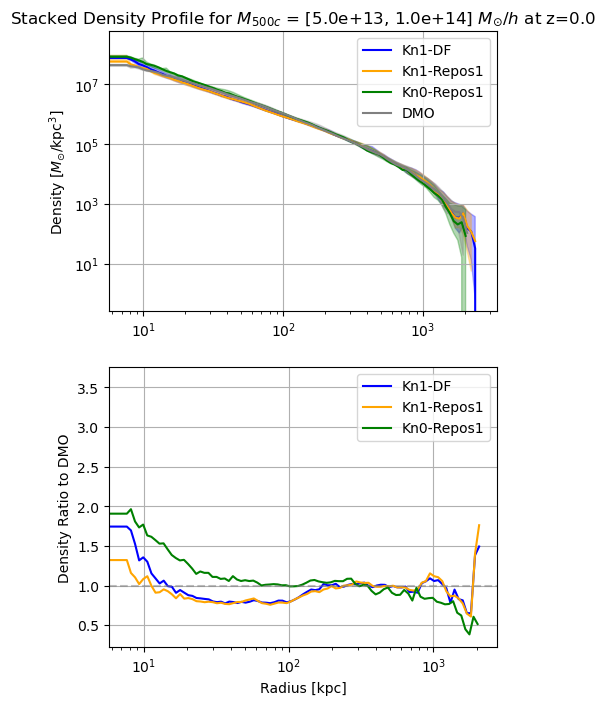

In [8]:
# stacked density profile, 5e13 to 1e14 Msun/h

colors = ['blue', 'orange', 'green']

m_lower, m_upper = 5e13, 1e14
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF = get_stacked_rho_profile(pigs_kn1DF[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF, 'Kn1-DF', colors[0])
r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1 = get_stacked_rho_profile(pigs_kn1R1[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1, 'Kn1-Repos1', colors[1])
r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1 = get_stacked_rho_profile(pigs_kn0R1[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1, 'Kn0-Repos1', colors[2])
r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo = get_stacked_rho_profile(pigs_dmo[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo, 'DMO', 'gray')

# ratio of hydro to DMO
r_common, ratio_kn1DF = get_profile_ratio(r_dmo, rho_dmo, r_kn1DF, rho_kn1DF)
axes[1].plot(r_common, ratio_kn1DF, label='Kn1-DF', color=colors[0])
r_common, ratio_kn1R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1R1, rho_kn1R1)
axes[1].plot(r_common, ratio_kn1R1, label='Kn1-Repos1', color=colors[1])
r_common, ratio_kn0R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn0R1, rho_kn0R1)
axes[1].plot(r_common, ratio_kn0R1, label='Kn0-Repos1', color=colors[2])

# horizontal line at y=1
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)


# grid true
for ax in axes:
    ax.grid(True)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_xlabel('Radius [kpc]')
axes[0].set_ylabel(r'Density [$M_{\odot}/\mathrm{kpc}^3$]')
axes[0].set_title(f'Stacked Density Profile for $M_{{500c}}$ = [{m_lower:.1e}, {m_upper:.1e}] $M_{{\odot}}/h$ at z={z_list[idx_z]}')

# legend
axes[0].legend()
axes[1].set_xscale('log')
axes[1].set_ylabel('Density Ratio to DMO')
axes[1].legend()
plt.show()

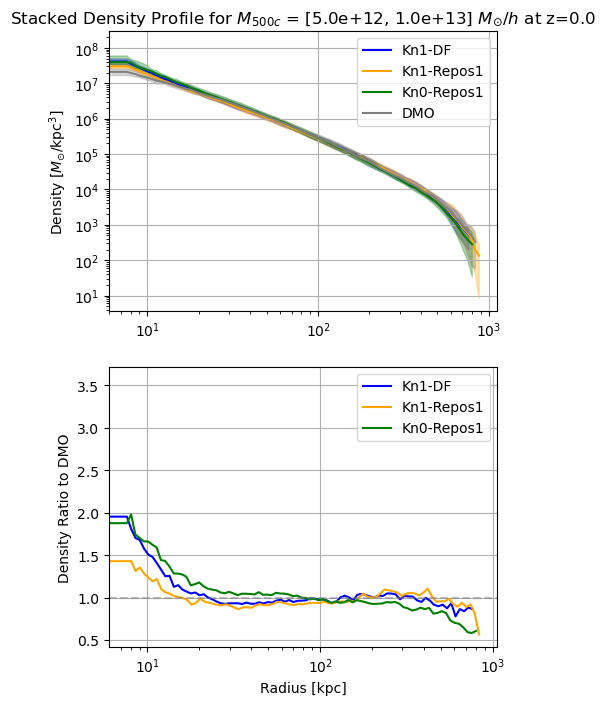

In [9]:
# stacked density profile, 5e12 to 1e13 Msun/h

colors = ['blue', 'orange', 'green']

m_lower, m_upper = 5e12, 1e13
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF = get_stacked_rho_profile(pigs_kn1DF[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF, 'Kn1-DF', colors[0])
r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1 = get_stacked_rho_profile(pigs_kn1R1[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1, 'Kn1-Repos1', colors[1])
r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1 = get_stacked_rho_profile(pigs_kn0R1[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1, 'Kn0-Repos1', colors[2])
r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo = get_stacked_rho_profile(pigs_dmo[idx_z], m_lower, m_upper)
plot_stacked(axes[0], r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo, 'DMO', 'gray')

# ratio of hydro to DMO
r_common, ratio_kn1DF = get_profile_ratio(r_dmo, rho_dmo, r_kn1DF, rho_kn1DF)
axes[1].plot(r_common, ratio_kn1DF, label='Kn1-DF', color=colors[0])
r_common, ratio_kn1R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn1R1, rho_kn1R1)
axes[1].plot(r_common, ratio_kn1R1, label='Kn1-Repos1', color=colors[1])
r_common, ratio_kn0R1 = get_profile_ratio(r_dmo, rho_dmo, r_kn0R1, rho_kn0R1)
axes[1].plot(r_common, ratio_kn0R1, label='Kn0-Repos1', color=colors[2])

# horizontal line at y=1
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)


# grid true
for ax in axes:
    ax.grid(True)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_xlabel('Radius [kpc]')
axes[0].set_ylabel(r'Density [$M_{\odot}/\mathrm{kpc}^3$]')
axes[0].set_title(f'Stacked Density Profile for $M_{{500c}}$ = [{m_lower:.1e}, {m_upper:.1e}] $M_{{\odot}}/h$ at z={z_list[idx_z]}')

# legend
axes[0].legend()
axes[1].set_xscale('log')
axes[1].set_ylabel('Density Ratio to DMO')
axes[1].legend()
plt.show()